# To-dos (13/11/23)

1. Remove fits to log, only use fit_short
2. Investigate the bad fits for the slices 
3. Confirm that the mcmc really does work for the entire fit
4. Plot the curve using [a, b, c, d] and play around with these values
5. Fix d = 0.5, and add "error parameters" for the temperature (eT + f) 
6. Run mcmc for this starting from e = 1, f = 0
7. Just use the entire series as your fit function

In [1]:
import emcee as mc #try markov chain monte carlo

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import data_analysis_script as da
import importlib as im
from scipy.optimize import curve_fit, minimize
import emcee as mc #try markov chain monte carlo

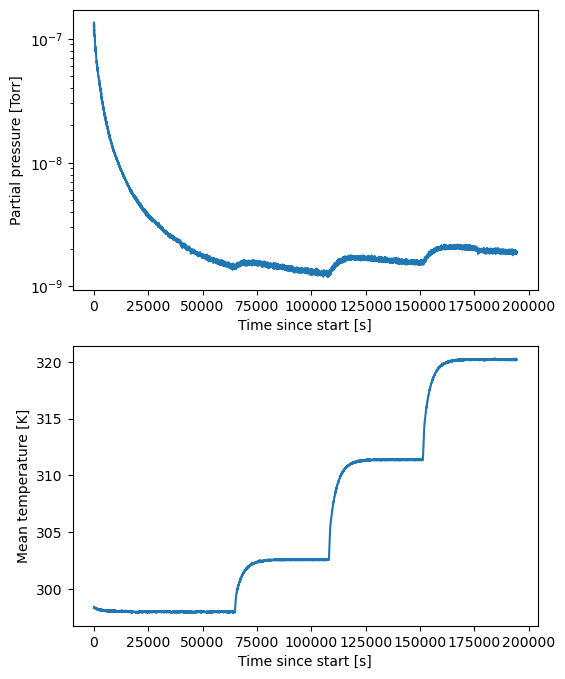

In [21]:
from data_analysis_script import Dataset
run_label = '2024-06-28' ## Change this to look at different runs
d = Dataset(run_label=run_label, gases=['N2'], data_path='20240628/')
d.GetData()
d.PlotSingleGas('N2')


In [22]:
time = np.array(d.data['N2']['Exposure_time'])
temp = np.array(d.data['N2']['Mean_temp']) #['Mean_temp'])
p = np.array(d.data['N2']['Partial_pressure'])

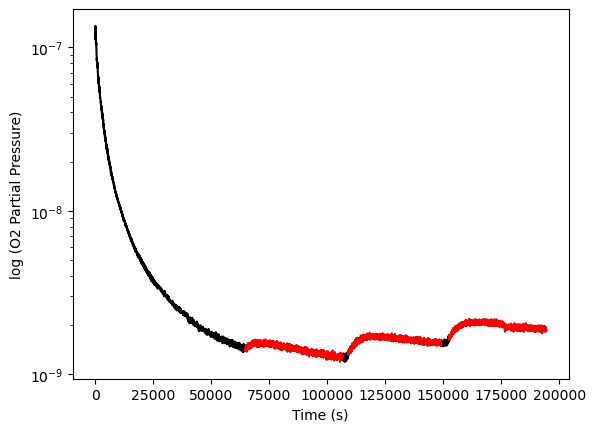

In [31]:
time_slices = [[64600, 85000+21600],
               [87500+21600, 127500+21600],
               [131000+21600, 175000+21600]]

plt.semilogy(time, p, 'k') # Plot the logarithm (base 10) of the partial pressure of O2 (oxygen) against time. 
plt.ylabel('log (O2 Partial Pressure)') 
plt.xlabel('Time (s)')

for ts in time_slices:
    gpts = (time > ts[0]) & (time < ts[1])
    plt.semilogy(time[gpts], p[gpts],'r')
#plt.ylim(2e-9, 9e-8)
#plt.xlim(12e4, 14e4)
#plt.savefig('teflo.png')
plt.show()

# MCMC

In [33]:

    
def combined_chisq_short(params, data_list, y):
    ds = Dataset("","","")
    ndsets = len(data_list)

    a, b, c, tau = params[0], params[1], params[2], params[3]


    tot_chisq = 0
    sig = 0.5e-9 ## error on values
    e_err = 0.1
    f_err = 1
    

    for n in range(ndsets):
        cdat = data_list[n]
        cy = y[n]
        curr_chisq = np.sum(((d.fitfunction_short_temp_offset(cdat, a, b, c, tau) - cy)/sig)**2) 
        if(not np.isnan(curr_chisq)):
            tot_chisq += curr_chisq
        else:
            tot_chisq += np.inf

    print(tot_chisq)
    return tot_chisq

time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]
tT = []
y = []
combined_data = []
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT.append((np.vstack((time[gpts], temp[gpts]))))
    y.append(p[gpts])
    combined_data.append([time[gpts], p[gpts]])
    
# plt.plot(tT[0], d.TrueTemp(tT[0], tT[1], res.x[3]))

# plt.show()



In [34]:
spars = np.array([2e-4, 5000, 8e-4, 5000])
print(combined_chisq_short(spars, tT, y))
res = minimize(combined_chisq_short, spars, args=(tT, y), method='Nelder-Mead', options={"maxiter": 100000})

35587.6022237652
35587.6022237652
35587.6022237652
35153.45060233907
38560.36287080002
35587.6022256296
35596.90292122177
31049.027597418066
24889.54839843652
30805.997950500285
27708.48461013688
22043.4996478967
11608.551755897439
7626.824113894087
7654.931566155615
3469.7725200896966
15738.93582837376
1695.981853917524
109360.14811381602
41465.829660151656
15025.072628755506
2462.369011063261
14618.674346458676
5683.078911274411
6475.218837334738
1465.5936182685755
16102.053668999884
2166.8925739399256
10465.612321599303
1410.2467846125087
2440.563502174245
1413.7896253302663
2815.010905445209
1261.7061494015124
2737.5775927645195
991.8992838647176
2983.50554179576
944.5616994801052
990.148179130293
1525.8693527038622
1057.1812081532798
1511.9741415368162
1000.9977428488829
1235.3500249861343
950.1014290656435
1203.1101795384216
936.3187403886667
953.9429840560308
1064.8830738546237
936.8511144068498
959.6446416884428
935.4363846227427
955.7389755049999
934.132911676763
963.590472008

104.94643819937357
104.3955002471515
104.66715137218652
104.4041766769127
104.36415215614875
104.45743971169571
104.52790912859928
104.36066144871174
104.33489839242853
104.36015167083951
104.45375986127905
104.35562152099496
104.36539093792976
104.34422583562719
104.35079114770909
104.34308597366723
104.32826336562428
104.35661131091024
104.37249589751173
104.3315302368772
104.3488895203013
104.33172505143159
104.3607193879474
104.33002927259386
104.32253390362533
104.32317515783772
104.3246261478102
104.32173478098856
104.32794871961178
104.32158467432447
104.3344843204335
104.31462700200908
104.31592912350618
104.3198274469552
104.31656236392541
104.30672572939255
104.30108874550942
104.31613945912858
104.30338801567328
104.30207217102085
104.31406015818604
104.29773543158012
104.30490518934035
104.29243261099029
104.29953913204902
104.28769616254769
104.28515845332194
104.28783416710344
104.26969338013346
104.25599658186675
104.27362596663968
104.25674082234366
104.27842973330078
1

In [35]:
print(res.x)

[ 4.82302737e-02  7.02500866e+03 -2.48831795e-01  1.73813676e+03]


IndexError: invalid index to scalar variable.

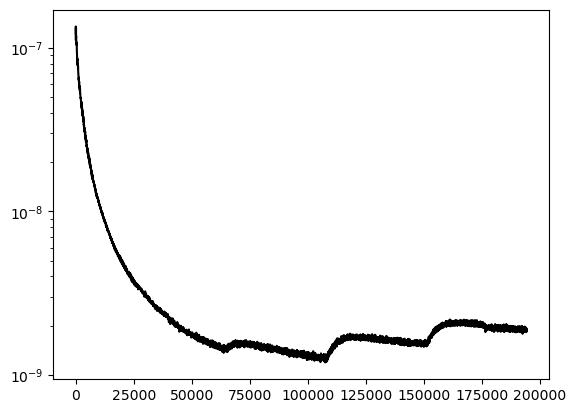

In [41]:

plt.figure()
plt.semilogy(time, p, 'k') # Plot the logarithm (base 10) of the partial pressure of O2 (oxygen) against time. 
for i in range(len(combined_data)):
    plt.plot(combined_data[i][0], np.abs(d.fitfunction_short_temp_offset(tT[i], *res.x)), 'r')
    
plt.ylabel('log (O2 Partial Pressure)') 
plt.xlabel('Time (s)')


plt.ylim(4e-9, 2.2e-8)


plt.show()


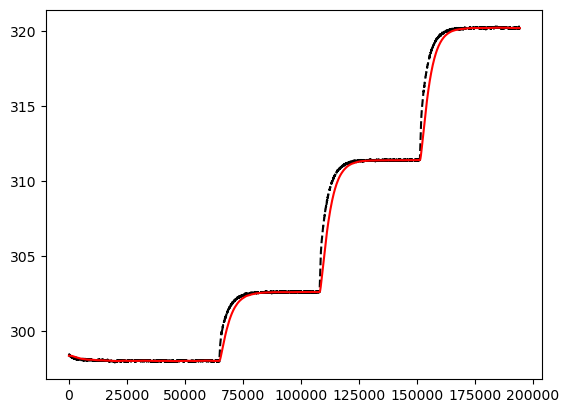

In [37]:

time = np.array(d.data['N2']['Exposure_time'])
temp = np.array(d.data['N2']['Mean_temp']) 
tau = res.x[3]

def exponential_decay(time, tau):
    return np.exp(-time/tau) * (time >= 0)


def smooth_step_function(time, temp, tau):

    dt = time[1] - time[0]  # Assuming t is evenly spaced
    decay_t = np.arange(0, len(time)) * dt  # Define time for the decay function
    decay = exponential_decay(decay_t, tau)
    Normdecay = decay/np.sum(decay) #Normalize decay function
    padded_data = np.pad(temp, (len(decay)-1, 0), mode='edge')  # Pad data with values similar to edge to resolve boundary issues
    smooth_step = np.convolve(padded_data, Normdecay, mode='valid') #Convolve two functions
    return smooth_step



plt.plot(time,temp,'k--')
plt.plot(time,  smooth_step_function(time, temp, tau), 'r')

plt.show()

In [38]:
print(res.x)

[ 4.82302737e-02  7.02500866e+03 -2.48831795e-01  1.73813676e+03]


bp: [ 3.37354956e+06  1.78408426e+04 -1.36687173e+04  1.00641381e+14]


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 90000.

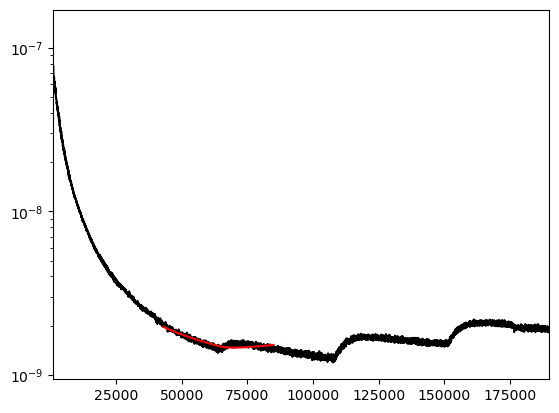

In [39]:
#Plotting Code

# time_slices = [[43000, 85000],
#                [87500, 127500],
#                [131000, 175000]]

#Plot with different fit parameters for each time slice

plt.figure()
plt.semilogy(time, p, 'k')

for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT = np.vstack((time[gpts], temp[gpts]))
    y = p[gpts]
    spars = [2e-4, 5000, 8e-4, 5000]
    bp, bc = curve_fit(d.fitfunction_short_temp_offset, tT, y, p0=spars, method='lm', maxfev=90000)
    plt.plot(tT[0], d.fitfunction_short_temp_offset(tT,*bp),'r')
    print('bp:', bp)
    plt.xlim(1e3, 19e4)
   

#Plot with the same fit parameters for all time slices
tT = []
y = []
combined_data = []
plt.figure()
plt.semilogy(time, p, 'k')
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT.append((np.vstack((time[gpts], temp[gpts]))))
    y.append(p[gpts])
    combined_data.append([time[gpts], p[gpts]])
spars = [2e-4, 5000, 8e-4, 5000] 
res = minimize(combined_chisq_short, spars, args=(tT, y))
bp = res.x


for j in range(len(time_slices)):
    tvals = combined_data[j][0]
    plt.plot(tvals, d.fitfunction_short_temp_offset(tT[j], *bp), 'r')
   
    

print('bp:', bp)

plt.ylabel('Pressure [mbar]')
plt.xlabel("Time [s]")
#plt.ylim(2e-9, 1e-7)
plt.xlim(1e3, 19e4)



In [ ]:
tvec = np.logspace(-6,0,1000)

maxn = 200

fval = np.zeros_like(tvec)
for n in range(maxn):
    fval += np.exp(-(np.pi*(2*n+1))**2*tvec)

plt.figure()
plt.loglog(tvec, fval)

In [ ]:
nwalkers, ndim = 100, 4


ffn = lambda p,d,y: -combined_chisq_short(p,d, y)

scaling_factors = np.array([1e-3, 4e+3, -1e-2, 4e+2,])
p0 = [spars + scaling_factors*0.001*np.random.randn(ndim) for i in range(nwalkers)]
 
sampler = mc.EnsembleSampler(nwalkers, ndim, ffn, args=(tT,y))
sampler.run_mcmc(p0, 4000, progress=True)


In [ ]:
# Extract the chain of samples
samples = sampler.get_chain()

# Calculate the median of each parameter across all walkers and steps
median_params = np.median(samples, axis=(0, 1))

# Print the median parameters
print("Median parameters:", median_params)
print('P0:', p0)

In [ ]:
fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["a", "b", "c", "tau"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
import corner

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)
print(flat_samples.shape)

fig = corner.corner(flat_samples, labels=labels)

In [ ]:
plt.figure()
plt.semilogy(time, p, 'k')
tT_final = []
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT_final.append((np.vstack((time[gpts],temp[gpts]))))
inds = np.random.randint(len(flat_samples), size=10)
for ind in inds:
    sample = flat_samples[ind]
    for j in range(len(time_slices)):
        tvals = combined_data[j][0]
        plt.plot(tvals, d.fitfunction_short_temp_offset(tT_final[j], sample[0], sample[1], sample[2], sample[3]), 'r', alpha=0.5)

plt.ylim(4e-9, 2.2e-8)
plt.ylabel('Pressure [mbar]')
plt.xlabel("Time [s]")



In [ ]:
from IPython.display import display, Math

CI = 10 ## L/s
Area = 0.01 ## m^2
mbar_to_Pa = 100
K = 0.22
p_atm = 1.01e5 #Pa
m_to_cm = 100
L_to_m3 = 1e-3
KbT = 4.14e-21 #J

mcmc_D0 = np.percentile((flat_samples[:, 0]*CI*mbar_to_Pa*L_to_m3/(K*p_atm*Area) * m_to_cm)**2, [16, 50, 84])
mcmc_Ea = np.percentile(flat_samples[:, 1], [16, 50, 84])

print("D0 [cm^2/s]: ", mcmc_D0)
print("Activation energy [K]: ", mcmc_Ea)
print(flat_samples[:,0])
